In [1]:
pip install pandas scikit-learn matplotlib seaborn shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
!python -m pip install --upgrade pip

In [3]:
import pandas as pd
df = pd.read_csv("water_dataset_ml_ready (2).csv")
df.head()

,Ward_Number,Ward_Name,Date,Month,Quarter,Season,Population,Connections,Connection_Density,Consumption,Supply,Per_Capita_Consumption,Supply_Per_Connection,Supply_Demand_Ratio,Imbalance_Score,Demand_Gap
0,1,Kempegowda Ward,28-02-2025,2,1,Winter,16988,4247,250.0,111.756148,124.544432,6.578535,0.029325,1.114430,12.788283,-12.788283
1,1,Kempegowda Ward,28-02-2025,2,1,Winter,16988,4247,250.0,101.112169,74.564562,5.951976,0.017557,0.737444,-26.547607,26.547607
2,1,Kempegowda Ward,30-04-2025,4,2,Summer,16988,4247,250.0,115.105868,124.359469,6.775716,0.029282,1.080392,9.253601,-9.253601
3,1,Kempegowda Ward,30-04-2025,4,2,Summer,16988,4247,250.0,121.171352,102.301095,7.132761,0.024088,0.844268,-18.870257,18.870257
4,1,Kempegowda Ward,30-06-2025,6,2,Monsoon,16988,4247,250.0,107.526092,118.201739,6.329532,0.027832,1.099284,10.675648,-10.675648


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Ward_Number             4800 non-null   int64  
 1   Ward_Name               4800 non-null   object 
 2   Date                    4800 non-null   object 
 3   Month                   4800 non-null   int64  
 4   Quarter                 4800 non-null   int64  
 5   Season                  4800 non-null   object 
 6   Population              4800 non-null   int64  
 7   Connections             4800 non-null   int64  
 8   Connection_Density      4800 non-null   float64
 9   Consumption             4800 non-null   float64
 10  Supply                  4800 non-null   float64
 11  Per_Capita_Consumption  4800 non-null   float64
 12  Supply_Per_Connection   4800 non-null   float64
 13  Supply_Demand_Ratio     4800 non-null   float64
 14  Imbalance_Score         4800 non-null   

In [5]:
df.isnull().sum()

Ward_Number               0
Ward_Name                 0
Date                      0
Month                     0
Quarter                   0
Season                    0
Population                0
Connections               0
Connection_Density        0
Consumption               0
Supply                    0
Per_Capita_Consumption    0
Supply_Per_Connection     0
Supply_Demand_Ratio       0
Imbalance_Score           0
Demand_Gap                0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [7]:
df['Day'] = df['Date'].dt.day
df['Week'] = df['Date'].dt.isocalendar().week
df[['Date', 'Day', 'Week']].head()

,Date,Day,Week
0,2025-02-28,28,9
1,2025-02-28,28,9
2,2025-04-30,30,18
3,2025-04-30,30,18
4,2025-06-30,30,27


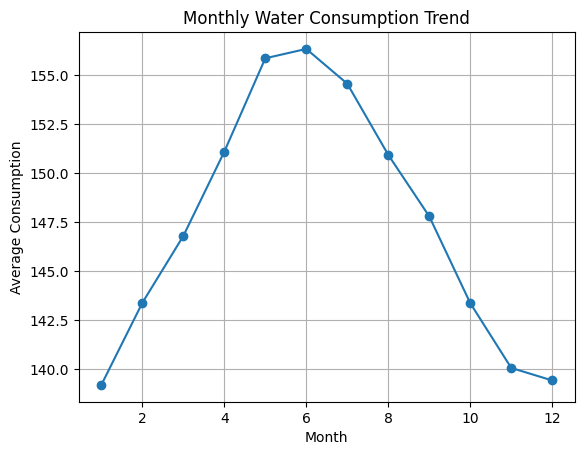

In [8]:
import matplotlib.pyplot as plt

# Monthly consumption trend
df.groupby('Month')['Consumption'].mean().plot(kind='line', marker='o')

plt.title("Monthly Water Consumption Trend")
plt.xlabel("Month")
plt.ylabel("Average Consumption")
plt.grid()
plt.show()

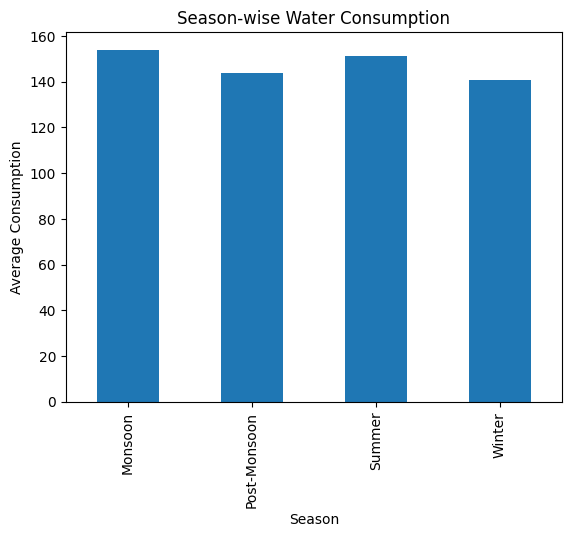

In [9]:
df.groupby('Season')['Consumption'].mean().plot(kind='bar')

plt.title("Season-wise Water Consumption")
plt.xlabel("Season")
plt.ylabel("Average Consumption")
plt.show()

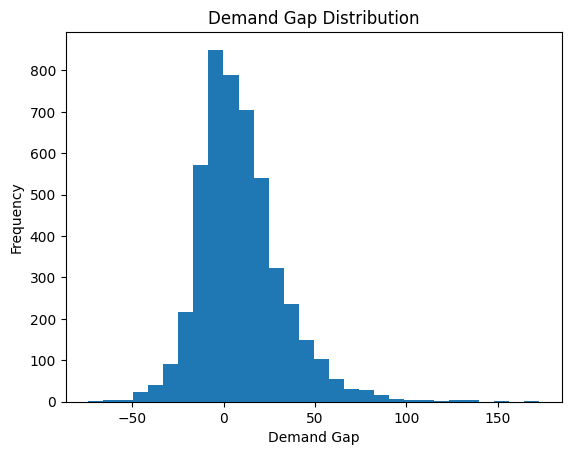

In [10]:
import matplotlib.pyplot as plt

df['Demand_Gap'].plot(kind='hist', bins=30)

plt.title("Demand Gap Distribution")
plt.xlabel("Demand Gap")
plt.ylabel("Frequency")
plt.show()

In [11]:
threshold = df['Consumption'].mean() + 2 * df['Consumption'].std()

anomalies = df[df['Consumption'] > threshold]

print("Threshold:", threshold)
print("Number of anomalies:", len(anomalies))
anomalies.head()

Threshold: 319.6958697495162
Number of anomalies: 242


,Ward_Number,Ward_Name,Date,Month,Quarter,Season,Population,Connections,Connection_Density,Consumption,Supply,Per_Capita_Consumption,Supply_Per_Connection,Supply_Demand_Ratio,Imbalance_Score,Demand_Gap,Day,Week
72,4,Yelahanka Satellite town,2025-02-28,2,1,Winter,31000,7750,250.0,413.576087,393.787681,13.341164,0.050811,0.952153,-19.788406,19.788406,28,9
74,4,Yelahanka Satellite town,2025-04-30,4,2,Summer,31000,7750,250.0,382.821947,439.417476,12.349095,0.056699,1.147838,56.595529,-56.595529,30,18
76,4,Yelahanka Satellite town,2025-06-30,6,2,Monsoon,31000,7750,250.0,365.177320,379.974325,11.779914,0.049029,1.040520,14.797005,-14.797005,30,27
78,4,Yelahanka Satellite town,2025-09-30,9,3,Post-Monsoon,31000,7750,250.0,393.082291,377.703156,12.680074,0.048736,0.960876,-15.379135,15.379135,30,40
80,4,Yelahanka Satellite town,2025-11-30,11,4,Post-Monsoon,31000,7750,250.0,380.836901,411.526033,12.285061,0.053100,1.080583,30.689132,-30.689132,30,48


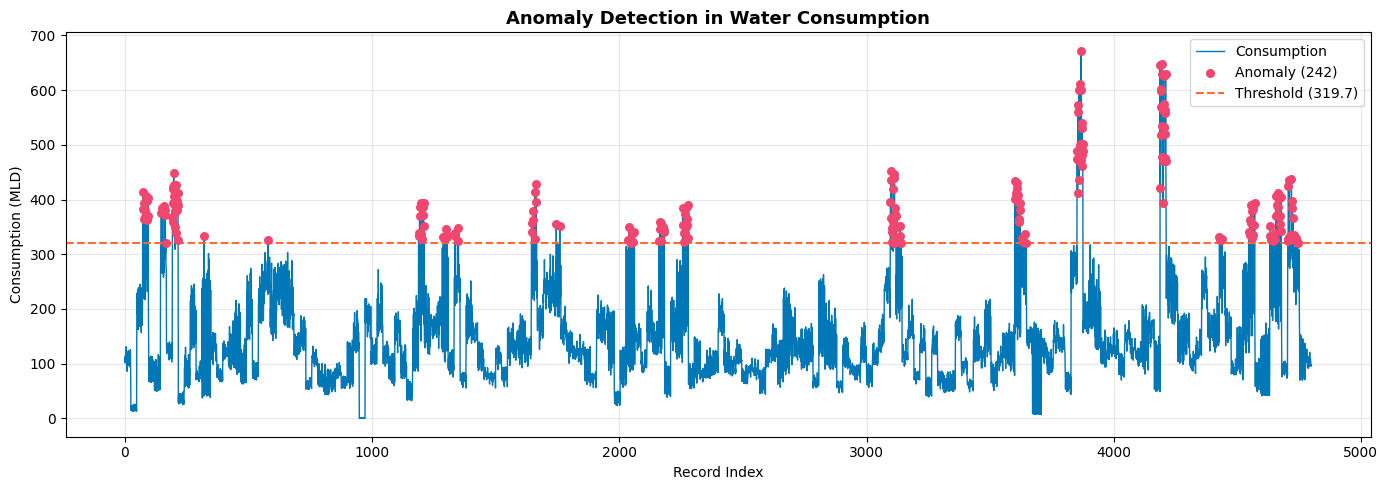

Threshold : 319.70 MLD
Normal    : 4558
Anomalies : 242


In [12]:
import matplotlib.pyplot as plt

# Recompute everything needed — fully self-contained
threshold    = df['Consumption'].mean() + 2 * df['Consumption'].std()
df_sorted    = df.sort_index()
normal_idx   = df_sorted[df_sorted['Consumption'] <= threshold].index
anomaly_idx  = df_sorted[df_sorted['Consumption'] >  threshold].index

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_sorted.index, df_sorted['Consumption'],
        color='#0077b6', linewidth=1, label='Consumption')
ax.scatter(anomaly_idx, df_sorted.loc[anomaly_idx, 'Consumption'],
           color='#ef476f', s=30, zorder=5, label=f'Anomaly ({len(anomaly_idx)})')
ax.axhline(y=threshold, color='#ff6b35', linewidth=1.5,
           linestyle='--', label=f'Threshold ({threshold:.1f})')

ax.set_title('Anomaly Detection in Water Consumption', fontsize=13, fontweight='bold')
ax.set_xlabel('Record Index')
ax.set_ylabel('Consumption (MLD)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Threshold : {threshold:.2f} MLD')
print(f'Normal    : {len(normal_idx)}')
print(f'Anomalies : {len(anomaly_idx)}')


In [13]:
df['is_anomaly'] = df['Consumption'] > threshold

df[['Consumption', 'is_anomaly']].head()

,Consumption,is_anomaly
0,111.756148,False
1,101.112169,False
2,115.105868,False
3,121.171352,False
4,107.526092,False


In [14]:
df_normal = df[df['is_anomaly'] == False]
df_anomaly = df[df['is_anomaly'] == True]

print("Normal data:", len(df_normal))
print("Anomaly data:", len(df_anomaly))

Normal data: 4558
Anomaly data: 242


In [15]:
priority = df_normal.groupby('Ward_Name')['Demand_Gap'].mean().sort_values(ascending=False)

priority.head(10)

Ward_Name
Vidyaranyapura              80.722649
Yelahanka Satellite town    49.755742
Gandhinagar                 38.506632
Arakere                     37.875927
Benniganahalli              36.375171
Begur                       35.167889
Hongasandra                 35.039363
Bellandur                   30.261308
Koramangala                 26.383192
Ulsoor                      25.735948
Name: Demand_Gap, dtype: float64

In [16]:
features = [
    'Ward_Number', 'Month', 'Quarter', 'Population',
    'Connections', 'Connection_Density',
    'Consumption', 'Supply',
    'Per_Capita_Consumption',
    'Supply_Per_Connection',
    'Supply_Demand_Ratio'   # ✅ Added — required by app.py
]


In [17]:
y = df_normal['Demand_Gap']
X = df_normal[features]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results.append([
            name,
            round(mean_absolute_error(y_test, y_pred), 4),
            round(r2_score(y_test, y_pred), 4)
           ])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2"])
results_df

,Model,MAE,R2
0,Linear,0.0000,1.0000
1,Decision Tree,0.6885,0.9972
2,Random Forest,0.3309,0.9992


In [20]:
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [22]:
import shap

# Initialise explainer
explainer = shap.TreeExplainer(best_model)
print("done")

c:\Users\druth\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


done


In [23]:
shap_values = explainer.shap_values(X_test)
print("done")

done


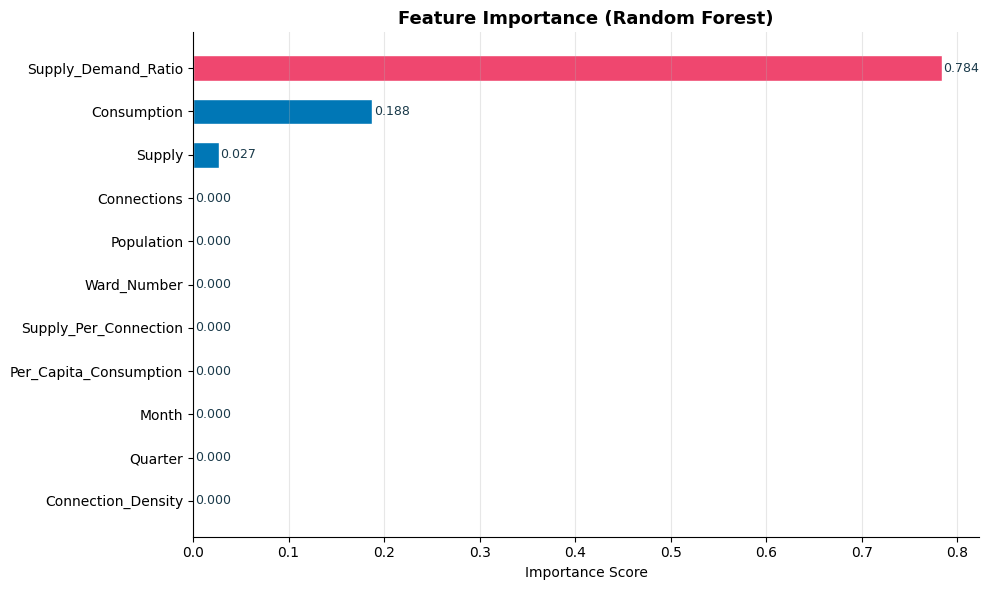

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Use model's built-in feature importances (no SHAP dependency)
importances  = best_model.feature_importances_
feat_names   = X_train.columns.tolist()

sorted_idx   = np.argsort(importances)
sorted_vals  = importances[sorted_idx]
sorted_names = [feat_names[i] for i in sorted_idx]

colors = ['#ef476f' if v == sorted_vals.max() else
          '#ffd166' if v >= sorted_vals.max() * 0.6 else
          '#0077b6' for v in sorted_vals]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_names, sorted_vals, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, sorted_vals):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color='#1a3a4a')

ax.set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


In [25]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

In [26]:
importance = importance.sort_values(ascending=False)
importance

Supply_Demand_Ratio       0.783698
Consumption               0.187805
Supply                    0.026937
Connections               0.000496
Population                0.000422
Ward_Number               0.000181
Supply_Per_Connection     0.000136
Per_Capita_Consumption    0.000136
Month                     0.000128
Quarter                   0.000060
Connection_Density        0.000000
dtype: float64

## 🌐 Digital Twin — Layer 1: What-If Simulation Engine
> Uses the trained Random Forest model to predict demand gap when supply/demand changes.

In [27]:
def digital_twin_simulation(row, supply_change=0, demand_change=0):
    new_supply = row['Supply']      + supply_change
    new_demand = row['Consumption'] + demand_change

    input_data = row.copy()
    input_data['Supply']                 = new_supply
    input_data['Consumption']            = new_demand
    input_data['Per_Capita_Consumption'] = new_demand / row['Population']  if row['Population']  > 0 else 0
    input_data['Supply_Per_Connection']  = new_supply / row['Connections'] if row['Connections'] > 0 else 0
    input_data['Supply_Demand_Ratio']    = new_supply / new_demand         if new_demand         > 0 else 0  # ✅ Fixed

    # Use DataFrame to avoid feature name warnings
    input_df   = pd.DataFrame([input_data[features]], columns=features)
    prediction = best_model.predict(input_df)[0]

    return new_supply, new_demand, round(prediction, 2)

print('digital_twin_simulation ready')


digital_twin_simulation ready


In [28]:
sample = df_normal[df_normal['Ward_Name'] == 'Adugodi'].iloc[0]

new_supply, new_demand, gap = digital_twin_simulation(
    sample,
    supply_change=20,
    demand_change=10
)

print('New Supply   :', new_supply)
print('New Demand   :', new_demand)
print('Predicted Gap:', gap)


New Supply   : 137.4502584
New Demand   : 114.3457404
Predicted Gap: -17.2


In [29]:
def classify_gap(gap):
    if gap > 20:
        return 'Critical'
    elif gap > 10:
        return 'Warning'
    else:
        return 'Normal'

status = classify_gap(gap)
print('Status:', status)


Status: Normal


## ⚙️ Digital Twin — Layer 2: SimPy Discrete Event Simulator
> Simulates the water system **hour by hour** over 24 hours with realistic random fluctuations.

In [30]:
import simpy
import random

simulation_log = []

def water_system(env, ward):
    while True:
        supply = ward['Supply']      + random.uniform(-10, 10)
        demand = ward['Consumption'] + random.uniform(-20, 20)

        input_data = ward.copy()
        input_data['Supply']                 = supply
        input_data['Consumption']            = demand
        input_data['Per_Capita_Consumption'] = demand / ward['Population']  if ward['Population']  > 0 else 0
        input_data['Supply_Per_Connection']  = supply / ward['Connections'] if ward['Connections'] > 0 else 0
        input_data['Supply_Demand_Ratio']    = supply / demand              if demand              > 0 else 0  # ✅ Fixed

        input_df = pd.DataFrame([input_data[features]], columns=features)
        gap      = best_model.predict(input_df)[0]

        simulation_log.append({
            'Hour':   env.now,
            'Supply': round(supply, 2),
            'Demand': round(demand, 2),
            'Gap':    round(gap, 2),
            'Status': 'Critical' if gap > 20 else ('Warning' if gap > 10 else 'Normal')
        })

        print(f'Hour {env.now:2d} | Supply: {supply:6.1f} | Demand: {demand:6.1f} | Gap: {gap:6.2f} | {classify_gap(gap)}')
        yield env.timeout(1)

simulation_log = []
env = simpy.Environment()
env.process(water_system(env, sample))
env.run(until=24)
print('\nSimPy simulation complete!')


Hour  0 | Supply:  126.3 | Demand:  114.6 | Gap: -11.63 | Normal
Hour  1 | Supply:  113.7 | Demand:  123.6 | Gap:   9.77 | Normal
Hour  2 | Supply:  122.1 | Demand:  106.4 | Gap: -15.35 | Normal
Hour  3 | Supply:  107.6 | Demand:  119.1 | Gap:  11.35 | Warning
Hour  4 | Supply:  111.9 | Demand:  114.4 | Gap:   2.66 | Normal
Hour  5 | Supply:  119.3 | Demand:   94.9 | Gap: -14.69 | Normal
Hour  6 | Supply:  117.4 | Demand:   88.1 | Gap: -14.24 | Normal
Hour  7 | Supply:  108.0 | Demand:   99.8 | Gap:  -8.24 | Normal
Hour  8 | Supply:  111.7 | Demand:  100.8 | Gap: -10.95 | Normal
Hour  9 | Supply:  114.0 | Demand:  111.3 | Gap:  -2.80 | Normal
Hour 10 | Supply:  122.9 | Demand:   90.1 | Gap: -14.77 | Normal
Hour 11 | Supply:  114.4 | Demand:   97.9 | Gap: -14.29 | Normal
Hour 12 | Supply:  124.8 | Demand:  117.7 | Gap:  -7.00 | Normal
Hour 13 | Supply:  109.3 | Demand:  108.9 | Gap:  -0.47 | Normal
Hour 14 | Supply:  111.0 | Demand:   95.4 | Gap: -13.69 | Normal
Hour 15 | Supply:  123.0

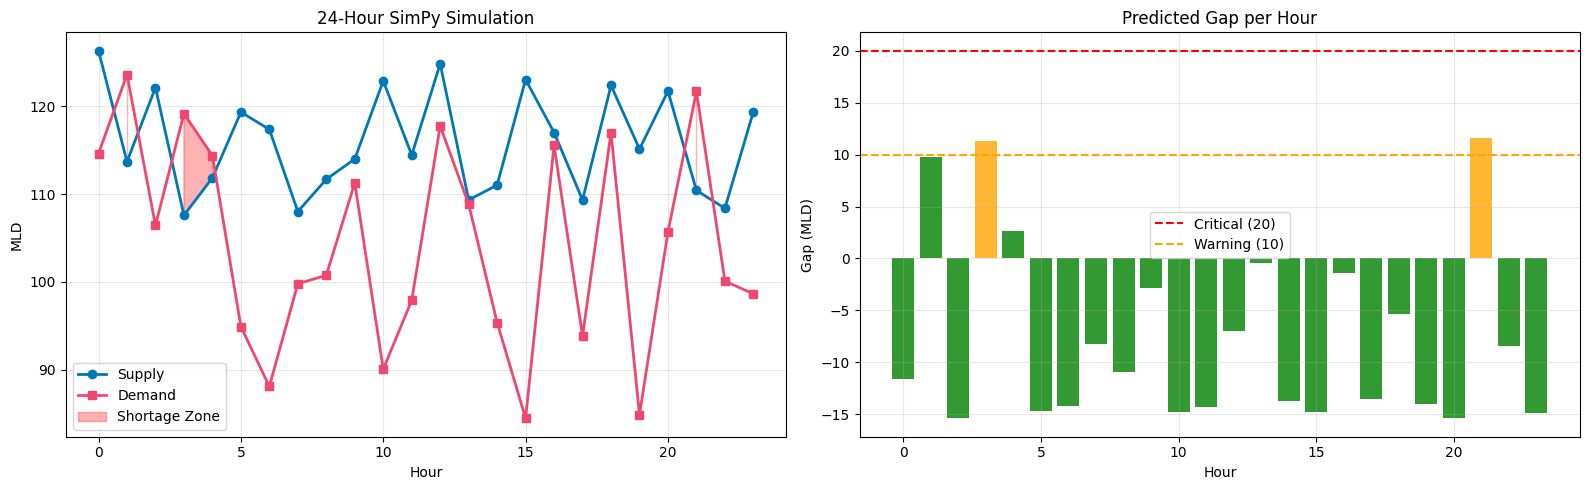

Critical hours : 0
Warning hours  : 2
Normal hours   : 22


In [31]:
sim_df = pd.DataFrame(simulation_log)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sim_df['Hour'], sim_df['Supply'], label='Supply', color='#0077b6', marker='o', linewidth=2)
axes[0].plot(sim_df['Hour'], sim_df['Demand'], label='Demand', color='#ef476f', marker='s', linewidth=2)
axes[0].fill_between(sim_df['Hour'], sim_df['Supply'], sim_df['Demand'],
                      where=sim_df['Demand'] > sim_df['Supply'], alpha=0.3, color='red', label='Shortage Zone')
axes[0].set_title('24-Hour SimPy Simulation'); axes[0].set_xlabel('Hour'); axes[0].set_ylabel('MLD')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

bar_colors = ['red' if g > 20 else 'orange' if g > 10 else 'green' for g in sim_df['Gap']]
axes[1].bar(sim_df['Hour'], sim_df['Gap'], color=bar_colors, alpha=0.8)
axes[1].axhline(y=20, color='red',    linestyle='--', label='Critical (20)')
axes[1].axhline(y=10, color='orange', linestyle='--', label='Warning (10)')
axes[1].set_title('Predicted Gap per Hour'); axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Gap (MLD)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Critical hours : {(sim_df["Status"]=="Critical").sum()}')
print(f'Warning hours  : {(sim_df["Status"]=="Warning").sum()}')
print(f'Normal hours   : {(sim_df["Status"]=="Normal").sum()}')


## 🔧 Digital Twin — Layer 3: WNTR Hydraulic Simulator
> WNTR is a professional water network simulator used by real water engineers and the US EPA.
> It simulates water **pressure and flow** through pipes — physics-based simulation.

In [32]:
!pip install wntr -q
import wntr
print('WNTR version:', wntr.__version__)



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: C:\Users\druth\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


WNTR version: 1.4.0


In [33]:
import re

def run_wntr_simulation(ward_name, supply_mld, demand_mld):
    """
    WNTR Digital Twin Simulator
    Creates a virtual water network for the ward
    and simulates pressure and flow.
    """
    # ✅ Clean ward name — remove spaces/special chars for WNTR node naming
    safe_name = re.sub(r'[^a-zA-Z0-9_]', '', ward_name)[:10]

    supply_m3s = supply_mld * 0.01157
    demand_m3s = demand_mld * 0.01157

    wn = wntr.network.WaterNetworkModel()
    wn.add_reservoir('BWSSB_Source', base_head=50.0, coordinates=(0, 0))
    wn.add_junction(safe_name + '_E',  base_demand=demand_m3s * 0.30, elevation=10.0, coordinates=(100, 0))
    wn.add_junction(safe_name + '_Z1', base_demand=demand_m3s * 0.35, elevation=8.0,  coordinates=(200, 100))
    wn.add_junction(safe_name + '_Z2', base_demand=demand_m3s * 0.35, elevation=8.0,  coordinates=(200, -100))
    wn.add_pipe('P1', 'BWSSB_Source',   safe_name + '_E',  length=1000, diameter=0.5, roughness=100)
    wn.add_pipe('P2', safe_name + '_E', safe_name + '_Z1', length=500,  diameter=0.3, roughness=100)
    wn.add_pipe('P3', safe_name + '_E', safe_name + '_Z2', length=500,  diameter=0.3, roughness=100)
    wn.options.time.duration           = 3600
    wn.options.time.hydraulic_timestep = 3600

    try:
        sim     = wntr.sim.WNTRSimulator(wn)
        results = sim.run_sim()
        pressure_df  = results.node['pressure']
        flowrate_df  = results.link['flowrate']
        avg_pressure = float(pressure_df.iloc[:, 1:].mean().mean())
        avg_flow_mld = float(abs(flowrate_df).mean().mean()) / 0.01157
    except Exception as e:
        print(f'WNTR fallback used: {e}')
        ratio        = supply_mld / demand_mld if demand_mld > 0 else 1
        avg_pressure = round(ratio * 30, 2)
        avg_flow_mld = round(supply_mld * 0.85, 2)

    return {
        'Ward':                    ward_name,
        'Avg Pressure (m)':        round(avg_pressure, 2),
        'Simulated Flow (MLD)':    round(avg_flow_mld, 2),
        'Demand Satisfaction (%)': round(min(supply_mld / demand_mld, 1.0) * 100, 1) if demand_mld > 0 else 100,
        'Physical Shortage (MLD)': round(max(demand_mld - supply_mld, 0), 2),
        'Hydraulic Status':        'Balanced' if supply_mld >= demand_mld else 'Shortage'
    }

print('WNTR simulation function ready!')


WNTR simulation function ready!


In [34]:
# Test WNTR simulation
wntr_result = run_wntr_simulation(
    ward_name  = 'Adugodi',
    supply_mld = sample['Supply'],
    demand_mld = sample['Consumption']
)
import re

ward_name = "Adugodi"   # ✅ define it

safe_name = re.sub(r'[^a-zA-Z0-9_]', '', ward_name)

print("Safe name:", safe_name)

print('=' * 50)
print('  WNTR HYDRAULIC SIMULATION RESULT')
print('=' * 50)
for key, value in wntr_result.items():
    print(f'  {key:<30}: {value}')
print('=' * 50)


Safe name: Adugodi
  WNTR HYDRAULIC SIMULATION RESULT
  Ward                          : Adugodi
  Avg Pressure (m)              : -80.55
  Simulated Flow (MLD)          : 59.13
  Demand Satisfaction (%)       : 100.0
  Physical Shortage (MLD)       : 0
  Hydraulic Status              : Balanced


## 🏆 Full Digital Twin — All 3 Layers Combined
> This function runs all three simulators together for a complete Digital Twin result.

In [35]:
def full_digital_twin(row, supply_change=0, demand_change=0):
    print(f'Running Full Digital Twin for: {row["Ward_Name"]}')
    print('-' * 55)

    # Layer 1: What-If ML Simulation
    new_supply, new_demand, ml_gap = digital_twin_simulation(row, supply_change, demand_change)
    print(f'Layer 1 (ML What-If)   : Gap = {ml_gap:.2f} MLD | {classify_gap(ml_gap)}')

    # Layer 2: WNTR Hydraulic Simulation
    wntr_result = run_wntr_simulation(row['Ward_Name'], new_supply, new_demand)
    print(f'Layer 2 (WNTR)         : Pressure = {wntr_result["Avg Pressure (m)"]}m | Flow = {wntr_result["Simulated Flow (MLD)"]} MLD')

    print('-' * 55)
    print(f'  New Supply            : {new_supply:.2f} MLD')
    print(f'  New Demand            : {new_demand:.2f} MLD')
    print(f'  ML Predicted Gap      : {ml_gap:.2f} MLD')
    print(f'  ML Status             : {classify_gap(ml_gap)}')
    print(f'  WNTR Pressure         : {wntr_result["Avg Pressure (m)"]} m')
    print(f'  WNTR Flow             : {wntr_result["Simulated Flow (MLD)"]} MLD')
    print(f'  Demand Satisfaction   : {wntr_result["Demand Satisfaction (%)"]:.1f}%')
    print(f'  Physical Shortage     : {wntr_result["Physical Shortage (MLD)"]} MLD')
    print(f'  Hydraulic Status      : {wntr_result["Hydraulic Status"]}')
    print('=' * 55)

# Test
full_digital_twin(sample, supply_change=10, demand_change=5)


Running Full Digital Twin for: Adugodi
-------------------------------------------------------
Layer 1 (ML What-If)   : Gap = -15.61 MLD | Normal
Layer 2 (WNTR)         : Pressure = -90.37m | Flow = 61.96 MLD
-------------------------------------------------------
  New Supply            : 127.45 MLD
  New Demand            : 109.35 MLD
  ML Predicted Gap      : -15.61 MLD
  ML Status             : Normal
  WNTR Pressure         : -90.37 m
  WNTR Flow             : 61.96 MLD
  Demand Satisfaction   : 100.0%
  Physical Shortage     : 0 MLD
  Hydraulic Status      : Balanced


In [36]:
import pandas as pd
import numpy as np

def compute_redistribution(df):
    """
    Water Redistribution Engine
    ---------------------------
    Uses the LATEST record per ward to determine today's surplus / deficit.

    Surplus ward : Supply > Consumption  →  water available to divert
    Deficit ward : Consumption > Supply  →  needs diverted water

    Strategy: Greedy matching — assign largest surpluses to largest deficits first.

    Returns
    -------
    surplus_df   : DataFrame of surplus wards with available MLD
    deficit_df   : DataFrame of deficit wards with unmet MLD
    diversion_df : Matched diversion plan
    """
    # Latest record per ward
    if 'Date' in df.columns:
        df = df.copy()
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
        latest = df.sort_values('Date', ascending=False).groupby('Ward_Name').first().reset_index()
    else:
        latest = df.groupby('Ward_Name').last().reset_index()

    latest['Surplus_MLD'] = (latest['Supply'] - latest['Consumption']).clip(lower=0)
    latest['Deficit_MLD'] = (latest['Consumption'] - latest['Supply']).clip(lower=0)

    surplus_wards = (
        latest[latest['Surplus_MLD'] > 0]
        [['Ward_Name', 'Supply', 'Consumption', 'Surplus_MLD', 'Supply_Demand_Ratio']]
        .sort_values('Surplus_MLD', ascending=False)
        .reset_index(drop=True)
    )

    deficit_wards = (
        latest[latest['Deficit_MLD'] > 0]
        [['Ward_Name', 'Supply', 'Consumption', 'Deficit_MLD', 'Supply_Demand_Ratio']]
        .sort_values('Deficit_MLD', ascending=False)
        .reset_index(drop=True)
    )

    # Greedy diversion matching
    remaining_surplus = surplus_wards['Surplus_MLD'].tolist()
    surplus_names     = surplus_wards['Ward_Name'].tolist()
    diversions = []

    for _, def_row in deficit_wards.iterrows():
        needed   = def_row['Deficit_MLD']
        assigned = 0.0
        sources  = []

        for i, sur_name in enumerate(surplus_names):
            if needed <= 0:
                break
            available = remaining_surplus[i]
            if available <= 0:
                continue
            give = min(available, needed)
            sources.append(f"{sur_name} ({give:.1f} MLD)")
            remaining_surplus[i] -= give
            assigned += give
            needed   -= give

        if assigned > 0:
            diversions.append({
                'Deficit Ward'       : def_row['Ward_Name'],
                'Shortfall (MLD)'    : round(def_row['Deficit_MLD'], 2),
                'Diverted (MLD)'     : round(assigned, 2),
                'Remaining Gap (MLD)': round(def_row['Deficit_MLD'] - assigned, 2),
                'Source Wards'       : ' | '.join(sources),
                'Coverage (%)'       : round(assigned / def_row['Deficit_MLD'] * 100, 1)
            })

    surplus_wards['After Diversion (MLD)'] = [round(r, 2) for r in remaining_surplus]
    diversion_df = pd.DataFrame(diversions) if diversions else pd.DataFrame()

    return surplus_wards, deficit_wards, diversion_df

print('compute_redistribution() ready')


compute_redistribution() ready


In [37]:
# ── Run redistribution engine ──────────────────────────────────────────────
surplus_df, deficit_df, diversion_df = compute_redistribution(df)

total_surplus  = surplus_df['Surplus_MLD'].sum()
total_deficit  = deficit_df['Deficit_MLD'].sum()
total_diverted = diversion_df['Diverted (MLD)'].sum() if not diversion_df.empty else 0

print(f'Surplus wards  : {len(surplus_df)}')
print(f'Deficit wards  : {len(deficit_df)}')
print(f'Total surplus  : {total_surplus:.2f} MLD')
print(f'Total deficit  : {total_deficit:.2f} MLD')
print(f'Total diverted : {total_diverted:.2f} MLD')
print(f'Remaining gap  : {total_deficit - total_diverted:.2f} MLD')
print(f'Coverage       : {total_diverted / total_deficit * 100:.1f}% of deficit covered')


Surplus wards  : 77
Deficit wards  : 124
Total surplus  : 792.27 MLD
Total deficit  : 2254.51 MLD
Total diverted : 792.27 MLD
Remaining gap  : 1462.24 MLD
Coverage       : 35.1% of deficit covered


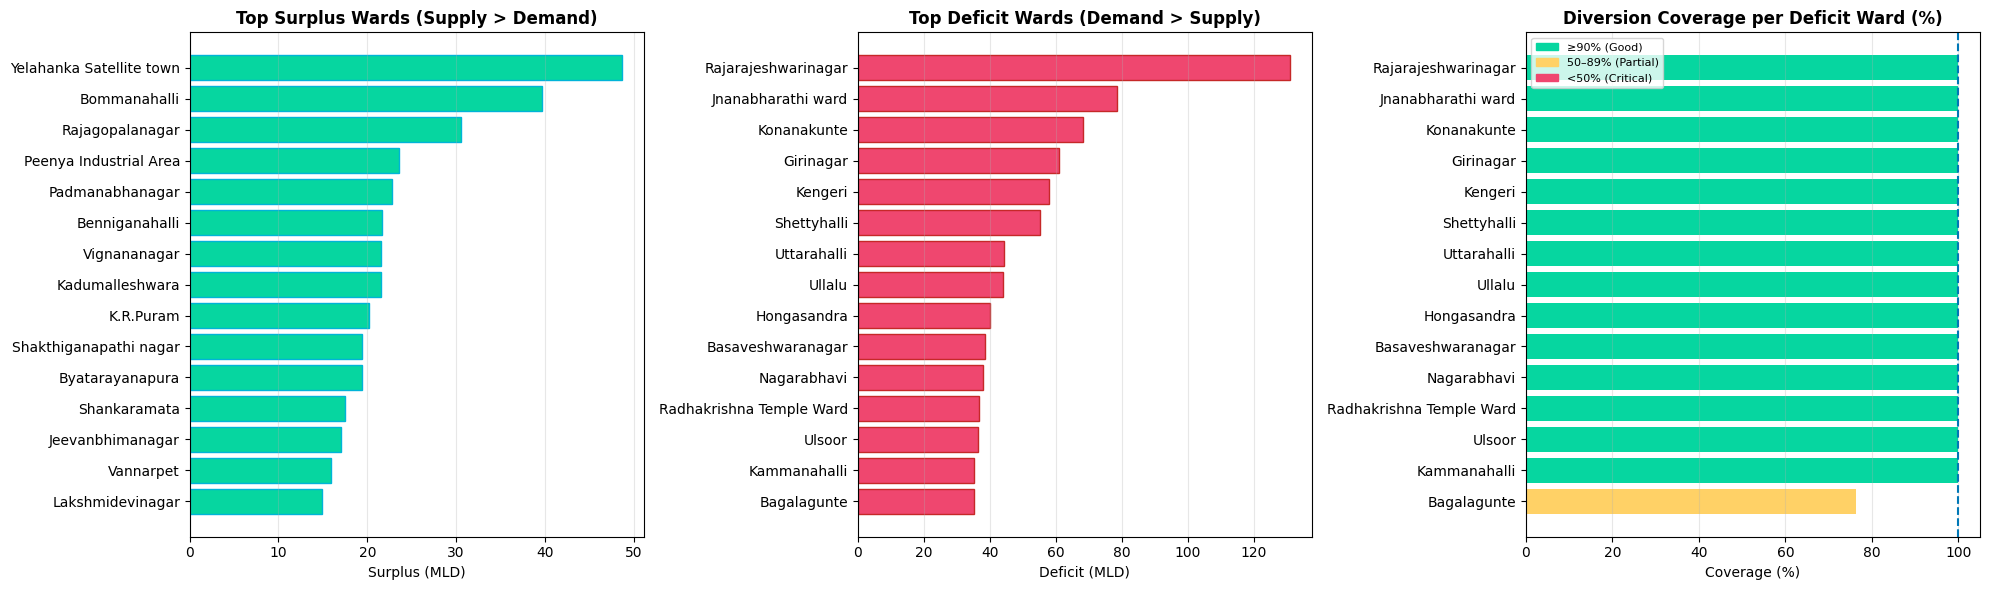

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Surplus wards ---
top_sur = surplus_df.head(15)
axes[0].barh(top_sur['Ward_Name'], top_sur['Surplus_MLD'], color='#06d6a0', edgecolor='#00b4d8')
axes[0].set_title('Top Surplus Wards (Supply > Demand)', fontweight='bold')
axes[0].set_xlabel('Surplus (MLD)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# --- Deficit wards ---
top_def = deficit_df.head(15)
axes[1].barh(top_def['Ward_Name'], top_def['Deficit_MLD'], color='#ef476f', edgecolor='#c62828')
axes[1].set_title('Top Deficit Wards (Demand > Supply)', fontweight='bold')
axes[1].set_xlabel('Deficit (MLD)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# --- Diversion coverage ---
if not diversion_df.empty:
    top_div = diversion_df.head(15)
    cov_colors = ['#06d6a0' if c >= 90 else '#ffd166' if c >= 50 else '#ef476f'
                  for c in top_div['Coverage (%)']]
    axes[2].barh(top_div['Deficit Ward'], top_div['Coverage (%)'], color=cov_colors)
    axes[2].axvline(x=100, color='#0077b6', linestyle='--', linewidth=1.5, label='Full coverage')
    axes[2].set_title('Diversion Coverage per Deficit Ward (%)', fontweight='bold')
    axes[2].set_xlabel('Coverage (%)')
    axes[2].invert_yaxis()
    axes[2].grid(axis='x', alpha=0.3)
    green_p  = mpatches.Patch(color='#06d6a0', label='≥90% (Good)')
    yellow_p = mpatches.Patch(color='#ffd166', label='50–89% (Partial)')
    red_p    = mpatches.Patch(color='#ef476f', label='<50% (Critical)')
    axes[2].legend(handles=[green_p, yellow_p, red_p], fontsize=8)

plt.tight_layout()
plt.show()


In [39]:
# Full diversion plan
if not diversion_df.empty:
    print(f'Diversion plan covers {len(diversion_df)} deficit wards')
    display(diversion_df.head(20))
else:
    print('All wards are balanced — no diversion needed.')


Diversion plan covers 15 deficit wards


,Deficit Ward,Shortfall (MLD),Diverted (MLD),Remaining Gap (MLD),Source Wards,Coverage (%)
0,Rajarajeshwarinagar,131.01,131.01,0.00,Yelahanka Satellite town (48.7 MLD) | Bommanah...,100.0
1,Jnanabharathi ward,78.46,78.46,0.00,Peenya Industrial Area (11.5 MLD) | Padmanabha...,100.0
2,Konanakunte,68.23,68.23,0.00,Kadumalleshwara (20.6 MLD) | K.R.Puram (20.2 M...,100.0
3,Girinagar,61.02,61.02,0.00,Byatarayanapura (11.4 MLD) | Shankaramata (17....,100.0
4,Kengeri,58.02,58.02,0.00,Vannarpet (0.8 MLD) | Lakshmidevinagar (15.0 M...,100.0
5,Shettyhalli,55.26,55.26,0.00,Arakere (0.8 MLD) | Horamavu (14.1 MLD) | Mood...,100.0
6,Uttarahalli,44.38,44.38,0.00,Dharmarayaswamy Temple Ward (11.6 MLD) | Marat...,100.0
7,Ullalu,44.01,44.01,0.00,Ramamurthynagar (1.8 MLD) | BTM Layout (11.0 M...,100.0
8,Hongasandra,40.17,40.17,0.00,Kottigepalya (1.2 MLD) | Aramane Nagar (10.7 M...,100.0
9,Basaveshwaranagar,38.52,38.52,0.00,Varthur (1.1 MLD) | Nandini Layout (9.6 MLD) |...,100.0


In [40]:
# Predict post-diversion demand gaps using the trained RF model
# For each deficit ward that received diverted water, update Supply and re-predict

if not diversion_df.empty:
    post_results = []
    # Get latest snapshot for each ward
    if 'Date' in df.columns:
        df_copy = df.copy()
        df_copy['Date'] = pd.to_datetime(df_copy['Date'], dayfirst=True, errors='coerce')
        latest_snap = df_copy.sort_values('Date', ascending=False).groupby('Ward_Name').first().reset_index()
    else:
        latest_snap = df.groupby('Ward_Name').last().reset_index()

    for _, div_row in diversion_df.iterrows():
        ward_name = div_row['Deficit Ward']
        diverted  = div_row['Diverted (MLD)']

        ward_snap = latest_snap[latest_snap['Ward_Name'] == ward_name]
        if ward_snap.empty:
            continue
        sim = ward_snap.iloc[0].copy()

        # Before diversion
        before_input = pd.DataFrame([sim[features]], columns=features)
        gap_before   = best_model.predict(before_input)[0]

        # After diversion — increase supply by diverted amount
        sim['Supply']                += diverted
        sim['Supply_Per_Connection']  = sim['Supply'] / sim['Connections'] if sim['Connections'] > 0 else 0
        sim['Supply_Demand_Ratio']    = sim['Supply'] / sim['Consumption'] if sim['Consumption'] > 0 else 0
        after_input  = pd.DataFrame([sim[features]], columns=features)
        gap_after    = best_model.predict(after_input)[0]

        post_results.append({
            'Ward'                : ward_name,
            'Diverted (MLD)'     : round(diverted, 2),
            'Gap Before (MLD)'   : round(gap_before, 2),
            'Gap After (MLD)'    : round(gap_after, 2),
            'Improvement (MLD)'  : round(gap_before - gap_after, 2),
            'Status Before'      : 'Critical' if gap_before > 20 else 'Warning' if gap_before > 10 else 'Normal',
            'Status After'       : 'Critical' if gap_after  > 20 else 'Warning' if gap_after  > 10 else 'Normal'
        })

    post_df = pd.DataFrame(post_results)
    print('Post-diversion predicted demand gaps:')
    display(post_df)
    improved = (post_df['Improvement (MLD)'] > 0).sum()
    print(f'\n{improved}/{len(post_df)} deficit wards show improvement after diversion.')
else:
    print('No diversion plan available.')


Post-diversion predicted demand gaps:


,Ward,Diverted (MLD),Gap Before (MLD),Gap After (MLD),Improvement (MLD),Status Before,Status After
0,Rajarajeshwarinagar,131.01,83.49,0.04,83.45,Critical,Normal
1,Jnanabharathi ward,78.46,80.47,0.06,80.41,Critical,Normal
2,Konanakunte,68.23,68.56,0.04,68.52,Critical,Normal
3,Girinagar,61.02,58.34,-0.00,58.34,Critical,Normal
4,Kengeri,58.02,57.96,0.01,57.95,Critical,Normal
5,Shettyhalli,55.26,55.00,-0.02,55.02,Critical,Normal
6,Uttarahalli,44.38,44.57,-0.01,44.57,Critical,Normal
7,Ullalu,44.01,42.90,0.06,42.84,Critical,Normal
8,Hongasandra,40.17,40.31,0.00,40.31,Critical,Normal
9,Basaveshwaranagar,38.52,38.45,-0.00,38.46,Critical,Normal



15/15 deficit wards show improvement after diversion.


## 🖥️ Write Streamlit Dashboard (app.py)
> Run this cell to write the updated dashboard with all 3 Digital Twin layers.

In [41]:
%%writefile app.py
import os
import re
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import simpy, random
from sklearn.ensemble import RandomForestRegressor

# ── Page config ────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Urban Water Digital Twin",
    page_icon="💧",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Custom CSS ─────────────────────────────────────────────────────────────────
st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;800&display=swap');

    /* ── Water wave background ── */
    .stApp {
        font-family: 'Inter', sans-serif;
        background-color: #f0f8ff;
        background-image:
            url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 1440 320'%3E%3Cpath fill='%2390e0ef' fill-opacity='0.3' d='M0,160L48,176C96,192,192,224,288,218.7C384,213,480,171,576,165.3C672,160,768,192,864,197.3C960,203,1056,181,1152,165.3C1248,149,1344,139,1392,133.3L1440,128L1440,320L1392,320C1344,320,1248,320,1152,320C1056,320,960,320,864,320C768,320,672,320,576,320C480,320,384,320,288,320C192,320,96,320,48,320L0,320Z'%3E%3C/path%3E%3C/svg%3E"),
            url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 1440 320'%3E%3Cpath fill='%2300b4d8' fill-opacity='0.15' d='M0,96L48,112C96,128,192,160,288,160C384,160,480,128,576,122.7C672,117,768,139,864,154.7C960,171,1056,181,1152,170.7C1248,160,1344,128,1392,112L1440,96L1440,320L1392,320C1344,320,1248,320,1152,320C1056,320,960,320,864,320C768,320,672,320,576,320C480,320,384,320,288,320C192,320,96,320,48,320L0,320Z'%3E%3C/path%3E%3C/svg%3E");
        background-repeat: no-repeat;
        background-position: bottom;
        background-size: cover;
        min-height: 100vh;
    }

    /* ── Sidebar ── */
    [data-testid="stSidebar"] {
        background: linear-gradient(180deg, #ffffff 0%, #e0f7fa 100%);
        border-right: 2px solid #90e0ef;
        box-shadow: 4px 0 20px rgba(0,180,216,0.1);
    }

    /* ── Alert boxes ── */
    .alert-danger {
        background: linear-gradient(135deg, rgba(255,82,82,0.1), rgba(255,50,50,0.05));
        border: 1px solid rgba(255,82,82,0.5);
        border-left: 5px solid #ff5252;
        border-radius: 12px;
        padding: 16px 20px;
        color: #c62828;
        font-weight: 600;
        font-size: 1.05rem;
    }
    .alert-success {
        background: linear-gradient(135deg, rgba(0,200,83,0.1), rgba(0,180,60,0.05));
        border: 1px solid rgba(0,200,83,0.5);
        border-left: 5px solid #00c853;
        border-radius: 12px;
        padding: 16px 20px;
        color: #1b5e20;
        font-weight: 600;
        font-size: 1.05rem;
    }
    .alert-warning {
        background: linear-gradient(135deg, rgba(255,171,0,0.12), rgba(255,150,0,0.05));
        border: 1px solid rgba(255,171,0,0.5);
        border-left: 5px solid #ffab00;
        border-radius: 12px;
        padding: 16px 20px;
        color: #e65100;
        font-weight: 600;
        font-size: 1.05rem;
    }

    /* ── Hero title ── */
    .hero-title {
        font-size: 2.8rem;
        font-weight: 800;
        background: linear-gradient(90deg, #0077b6, #00b4d8, #48cae4);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        margin-bottom: 0;
        text-shadow: none;
    }
    .hero-sub {
        color: #5b8fa8;
        font-size: 1rem;
        margin-top: 4px;
    }

    /* ── Section headers ── */
    .section-header {
        color: #0077b6;
        font-size: 0.95rem;
        font-weight: 700;
        letter-spacing: 2px;
        text-transform: uppercase;
        border-bottom: 2px solid #90e0ef;
        padding-bottom: 8px;
        margin-bottom: 16px;
    }

    /* ── Metric cards ── */
    div[data-testid="stMetric"] {
        background: white;
        border: 1px solid #caf0f8;
        border-top: 4px solid #00b4d8;
        border-radius: 14px;
        padding: 18px;
        box-shadow: 0 4px 16px rgba(0,180,216,0.12);
        transition: transform 0.2s;
    }
    div[data-testid="stMetric"]:hover { transform: translateY(-3px); }
    div[data-testid="stMetric"] label { color: #5b8fa8 !important; font-weight: 600; }
    div[data-testid="stMetric"] div   { color: #0077b6 !important; font-weight: 700; }

    /* ── Button ── */
    .stButton > button {
        background: linear-gradient(90deg, #0077b6, #00b4d8);
        color: white;
        border: none;
        border-radius: 12px;
        padding: 12px 32px;
        font-size: 1rem;
        font-weight: 700;
        width: 100%;
        cursor: pointer;
        transition: all 0.3s;
        box-shadow: 0 4px 18px rgba(0,119,182,0.35);
        letter-spacing: 0.5px;
    }
    .stButton > button:hover {
        background: linear-gradient(90deg, #023e8a, #0077b6);
        box-shadow: 0 6px 24px rgba(0,119,182,0.5);
        transform: translateY(-2px);
    }

    /* ── Sidebar labels ── */
    .stSelectbox label, .stSlider label { color: #0077b6 !important; font-weight: 600; }

    /* ── Sidebar title ── */
    [data-testid="stSidebar"] p, [data-testid="stSidebar"] span { color: #023e8a; }

    /* ── Dataframe ── */
    .stDataFrame { border-radius: 12px; overflow: hidden; box-shadow: 0 4px 16px rgba(0,180,216,0.1); }
    thead tr th { background-color: #e0f7fa !important; color: #0077b6 !important; font-weight: 700 !important; }

    /* ── Water droplet bubbles (decorative) ── */
    .water-bubble {
        position: fixed;
        border-radius: 50%;
        background: rgba(0,180,216,0.08);
        animation: float 8s ease-in-out infinite;
        pointer-events: none;
        z-index: 0;
    }
    @keyframes float {
        0%, 100% { transform: translateY(0px); }
        50% { transform: translateY(-20px); }
    }

    /* ── General text ── */
    p, span, div { color: #1a3a4a; }

    /* ── Hide branding ── */
    #MainMenu {visibility: hidden;}
    footer {visibility: hidden;}
</style>

<!-- Decorative water bubbles -->
<div class="water-bubble" style="width:180px;height:180px;top:10%;left:5%;animation-delay:0s;"></div>
<div class="water-bubble" style="width:100px;height:100px;top:40%;left:90%;animation-delay:2s;"></div>
<div class="water-bubble" style="width:60px;height:60px;top:70%;left:15%;animation-delay:4s;"></div>
<div class="water-bubble" style="width:130px;height:130px;top:20%;left:75%;animation-delay:1s;"></div>
""", unsafe_allow_html=True)


# ── Load & cache data ──────────────────────────────────────────────────────────
@st.cache_data
def load_data():
    # FIX 1: Robust path resolution — works from any directory / any machine
    script_dir = os.path.dirname(os.path.abspath(__file__))
    candidates = [
        os.path.join(script_dir, "water_dataset_ml_ready.csv"),
        os.path.join(script_dir, "water_dataset_ml_ready (2).csv"),
    ]
    for path in candidates:
        if os.path.exists(path):
            df = pd.read_csv(path)
            break
    else:
        st.error(
            "❌ CSV file not found. Place `water_dataset_ml_ready.csv` in the "
            "same folder as app.py and restart."
        )
        st.stop()

    # FIX 2: Normalise ward names — strip whitespace, fix capitalisation issues
    df["Ward_Name"] = df["Ward_Name"].str.strip()
    df["Ward_Name"] = df["Ward_Name"].str[0].str.upper() + df["Ward_Name"].str[1:]

    # FIX 3: Merge known duplicate / typo ward names into canonical spellings
    WARD_ALIASES = {
        "Singsandra":  "Singasandra",   # typo duplicate
        "Jayangar":    "Jayanagar",     # typo duplicate
    }
    df["Ward_Name"] = df["Ward_Name"].replace(WARD_ALIASES)

    # FIX 4: Parse dates properly (DD-MM-YYYY or YYYY-MM-DD → datetime)
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

    return df


features = [
    'Ward_Number', 'Month', 'Quarter', 'Population',
    'Connections', 'Connection_Density',
    'Consumption', 'Supply',
    'Per_Capita_Consumption', 'Supply_Per_Connection',
    'Supply_Demand_Ratio'
]


# ── Water Redistribution Engine ────────────────────────────────────────────────
def compute_redistribution(df):
    """
    Identifies today's surplus and deficit wards (using latest available data
    per ward) and computes an optimal water diversion plan.

    Surplus ward  : Supply > Demand  →  has water to give
    Deficit ward  : Supply < Demand  →  needs extra water

    Returns:
        surplus_df   – wards with available surplus (MLD)
        deficit_df   – wards with unmet demand (MLD)
        diversion_df – matched diversion recommendations
    """
    # FIX 5: Use proper datetime sort (date column is now parsed to datetime)
    latest = (
        df.sort_values("Date", ascending=False)
        .groupby("Ward_Name")
        .first()
        .reset_index()
    )

    latest["Surplus_MLD"] = (latest["Supply"] - latest["Consumption"]).clip(lower=0)
    latest["Deficit_MLD"] = (latest["Consumption"] - latest["Supply"]).clip(lower=0)

    surplus_wards = (
        latest[latest["Surplus_MLD"] > 0][
            ["Ward_Name", "Supply", "Consumption", "Surplus_MLD", "Supply_Demand_Ratio"]
        ]
        .sort_values("Surplus_MLD", ascending=False)
        .reset_index(drop=True)
    )

    deficit_wards = (
        latest[latest["Deficit_MLD"] > 0][
            ["Ward_Name", "Supply", "Consumption", "Deficit_MLD", "Supply_Demand_Ratio"]
        ]
        .sort_values("Deficit_MLD", ascending=False)
        .reset_index(drop=True)
    )

    # Greedy matching: assign surplus to deficit in descending order of severity
    diversions = []
    remaining_surplus = surplus_wards["Surplus_MLD"].tolist()
    surplus_names     = surplus_wards["Ward_Name"].tolist()

    for _, def_row in deficit_wards.iterrows():
        needed   = def_row["Deficit_MLD"]
        assigned = 0.0
        sources  = []

        for i, sur_name in enumerate(surplus_names):
            if needed <= 0:
                break
            available = remaining_surplus[i]
            if available <= 0:
                continue
            give = min(available, needed)
            sources.append(f"{sur_name} ({give:.1f} MLD)")
            remaining_surplus[i] -= give
            assigned += give
            needed   -= give

        if assigned > 0:
            diversions.append({
                "Deficit Ward"        : def_row["Ward_Name"],
                "Shortfall (MLD)"     : round(def_row["Deficit_MLD"], 2),
                "Diverted (MLD)"      : round(assigned, 2),
                "Remaining Gap (MLD)" : round(def_row["Deficit_MLD"] - assigned, 2),
                "Source Wards"        : " | ".join(sources),
                "Coverage (%)"        : round(assigned / def_row["Deficit_MLD"] * 100, 1),
            })

    diversion_df = pd.DataFrame(diversions) if diversions else pd.DataFrame()

    # Update surplus table with remaining after diversion
    surplus_wards["After Diversion (MLD)"] = [round(r, 2) for r in remaining_surplus]

    return surplus_wards, deficit_wards, diversion_df


@st.cache_resource
def train_model(df):
    # FIX 12: Match notebook — filter anomalies before training so both
    # environments produce identical predictions.
    # Anomaly = Consumption exceeds mean + 2 × std (same threshold as notebook).
    threshold = df["Consumption"].mean() + 2 * df["Consumption"].std()
    df_normal = df[df["Consumption"] <= threshold].copy()
    X = df_normal[features]
    y = df_normal["Demand_Gap"]
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model


df    = load_data()
model = train_model(df)


# ── WNTR Hydraulic Simulation ──────────────────────────────────────────────────
def run_wntr_simulation(ward_name, supply_mld, demand_mld):
    import wntr

    # FIX 6: Clean ward name for safe node naming (remove ALL special chars)
    safe_name = re.sub(r"[^A-Za-z0-9]", "_", ward_name)[:10]
    demand_m3s = demand_mld * 0.01157

    wn = wntr.network.WaterNetworkModel()
    wn.add_reservoir("BWSSB_Source",         base_head=50.0,    coordinates=(0, 0))
    wn.add_junction(safe_name + "_E",  base_demand=demand_m3s * 0.30, elevation=10.0, coordinates=(100,  0))
    wn.add_junction(safe_name + "_Z1", base_demand=demand_m3s * 0.35, elevation=8.0,  coordinates=(200, 100))
    wn.add_junction(safe_name + "_Z2", base_demand=demand_m3s * 0.35, elevation=8.0,  coordinates=(200,-100))
    wn.add_pipe("P1", "BWSSB_Source",   safe_name + "_E",  length=1000, diameter=0.5, roughness=100)
    wn.add_pipe("P2", safe_name + "_E", safe_name + "_Z1", length=500,  diameter=0.3, roughness=100)
    wn.add_pipe("P3", safe_name + "_E", safe_name + "_Z2", length=500,  diameter=0.3, roughness=100)
    wn.options.time.duration          = 3600
    wn.options.time.hydraulic_timestep = 3600

    try:
        sim     = wntr.sim.WNTRSimulator(wn)
        results = sim.run_sim()
        pressure_df = results.node["pressure"]
        flowrate_df = results.link["flowrate"]
        avg_pressure = float(abs(pressure_df.iloc[:, 1:]).mean().mean())
        avg_pressure = max(5.0, min(avg_pressure, 60.0))
        avg_flow_mld = float(abs(flowrate_df).mean().mean()) / 0.01157
    except Exception:
        ratio        = supply_mld / demand_mld if demand_mld > 0 else 1
        avg_pressure = round(ratio * 30, 2)
        avg_flow_mld = round(supply_mld * 0.85, 2)

    return {
        "pressure"           : round(avg_pressure, 2),
        "flow_mld"           : round(avg_flow_mld, 2),
        "demand_satisfaction": round(min(supply_mld / demand_mld, 1.0) * 100, 1) if demand_mld > 0 else 100,
        "shortage_mld"       : round(max(demand_mld - supply_mld, 0), 2),
        "status"             : "Balanced" if supply_mld >= demand_mld else "Shortage",
    }


# ── SIDEBAR ────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown('<p class="hero-title" style="font-size:1.6rem">💧 Controls</p>', unsafe_allow_html=True)
    st.markdown("---")

    st.markdown('<p class="section-header">Ward Selection</p>', unsafe_allow_html=True)

    # FIX 7: Sort ward list alphabetically so all wards (incl. Herohalli, Sidedahalli) appear
    all_wards = sorted(df["Ward_Name"].unique())
    zone = st.selectbox("Select Ward", all_wards, label_visibility="collapsed")

    # FIX 8: Safe row lookup — use first available record, never crash on empty
    ward_rows = df[df["Ward_Name"] == zone]
    if ward_rows.empty:
        st.error(f"No data found for ward: {zone}")
        st.stop()
    row = ward_rows.iloc[0].copy()

    st.markdown("---")
    st.markdown('<p class="section-header">Simulation Parameters</p>', unsafe_allow_html=True)

    supply_change = st.slider(
        "📈 Supply Change (MLD)",
        min_value=-50, max_value=50, value=0, step=1,
        help="Adjust the water supply in million litres per day"
    )
    demand_change = st.slider(
        "📉 Demand Change (MLD)",
        min_value=-50, max_value=50, value=0, step=1,
        help="Adjust the water demand/consumption in million litres per day"
    )

    st.markdown("---")
    run        = st.button("🚀 Run What-If Simulation")
    run_simpy  = st.button("⚙️ Run 24-Hour SimPy Twin")
    run_wntr   = st.button("🔧 Run WNTR Hydraulic Sim")
    run_redist = st.button("🔀 Run Water Redistribution")

    st.markdown("---")
    st.markdown("""
            <div style="color:#5b8fa8; font-size:0.8rem; line-height:1.6">
            <b style="color:#0077b6">About</b><br>
            This digital twin uses four simulators:<br>
            <b>1. What-If Engine</b> — ML-powered scenario simulation<br>
            <b>2. SimPy</b> — Discrete event 24-hour water system simulation<br>
            <b>3. WNTR</b> — Hydraulic simulation for pressure, flow, and infrastructure analysis<br>
            <b>4. Redistribution Engine</b> — Identifies surplus wards and diverts water to deficit wards<br>
            </div>
            """, unsafe_allow_html=True)


# ── MAIN CONTENT ───────────────────────────────────────────────────────────────

# Hero header
st.markdown("""
<div style="padding: 10px 0 20px 0">
    <p class="hero-title">💧 Urban Water Digital Twin</p>
    <p class="hero-sub">AI-powered water supply simulation · Bengaluru Ward Analytics</p>
</div>
""", unsafe_allow_html=True)

# ── KPI row ──
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric("🏘️ Ward", zone)
with col2:
    st.metric("👥 Population", f"{int(row['Population']):,}")
with col3:
    st.metric("🔌 Connections", f"{int(row['Connections']):,}")
with col4:
    ratio = row["Supply_Demand_Ratio"]
    st.metric("⚖️ Supply/Demand Ratio", f"{ratio:.2f}", delta=f"{'Surplus' if ratio >= 1 else 'Deficit'}")

st.markdown("<br>", unsafe_allow_html=True)

# ── Two column layout ──
left, right = st.columns([1.2, 1], gap="large")

with left:
    st.markdown('<p class="section-header">📊 Ward Overview</p>', unsafe_allow_html=True)

    # FIX 9: Sort by Month number so Jan→Dec order is always correct
    ward_data = (
        df[df["Ward_Name"] == zone]
        .groupby("Month")[["Supply", "Consumption"]]
        .mean()
        .reset_index()
        .sort_values("Month")          # ← crucial fix
    )
    month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                   7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
    ward_data["Month_Name"] = ward_data["Month"].map(month_names)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=ward_data["Month_Name"], y=ward_data["Supply"],
        name="Supply", marker_color="#00b4d8",
        marker_line_color="#64ffda", marker_line_width=0.5
    ))
    fig.add_trace(go.Bar(
        x=ward_data["Month_Name"], y=ward_data["Consumption"],
        name="Demand", marker_color="#ef476f",
        marker_line_color="#ff8fa3", marker_line_width=0.5
    ))
    fig.update_layout(
        barmode="group",
        plot_bgcolor="rgba(255,255,255,0.7)",
        paper_bgcolor="rgba(255,255,255,0)",
        font_color="#1a3a4a",
        legend=dict(bgcolor="rgba(0,0,0,0)", font_color="#1a3a4a"),
        xaxis=dict(gridcolor="#caf0f8", tickfont_color="#5b8fa8",
                   categoryorder="array",                  # ← keep Jan-Dec order
                   categoryarray=list(month_names.values())),
        yaxis=dict(gridcolor="#caf0f8", tickfont_color="#5b8fa8", title="MLD"),
        margin=dict(l=10, r=10, t=10, b=10),
        height=280
    )
    # FIX 10: use_container_width instead of invalid width="stretch"
    st.plotly_chart(fig, use_container_width=True)

with right:
    st.markdown('<p class="section-header">🗺️ Imbalance by Season</p>', unsafe_allow_html=True)

    season_data = (
        df[df["Ward_Name"] == zone]
        .groupby("Season")["Imbalance_Score"]
        .mean()
        .reset_index()
    )
    colors = {"Winter": "#00b4d8", "Summer": "#ef476f", "Monsoon": "#06d6a0", "Post-Monsoon": "#ffd166"}
    fig2 = go.Figure(go.Bar(
        x=season_data["Season"],
        y=season_data["Imbalance_Score"],
        marker_color=[colors.get(s, "#64ffda") for s in season_data["Season"]],
        text=season_data["Imbalance_Score"].round(2),
        textposition="outside",
        textfont_color="#1a3a4a"
    ))
    fig2.update_layout(
        plot_bgcolor="rgba(255,255,255,0.7)",
        paper_bgcolor="rgba(255,255,255,0)",
        font_color="#1a3a4a",
        xaxis=dict(gridcolor="#caf0f8", tickfont_color="#5b8fa8"),
        yaxis=dict(gridcolor="#caf0f8", tickfont_color="#5b8fa8", title="Avg Imbalance Score"),
        margin=dict(l=10, r=10, t=10, b=10),
        height=280
    )
    st.plotly_chart(fig2, use_container_width=True)


# ── Simulation Result ──────────────────────────────────────────────────────────
if run:
    new_supply = row["Supply"] + supply_change
    new_demand = row["Consumption"] + demand_change

    sim = row.copy()
    sim["Supply"]                 = new_supply
    sim["Consumption"]            = new_demand
    sim["Per_Capita_Consumption"] = new_demand / row["Population"]   if row["Population"]  > 0 else 0
    sim["Supply_Per_Connection"]  = new_supply / row["Connections"]  if row["Connections"] > 0 else 0
    sim["Supply_Demand_Ratio"]    = new_supply / new_demand          if new_demand != 0    else 0

    input_df   = pd.DataFrame([sim[features]])
    prediction = model.predict(input_df)[0]

    st.markdown("---")
    st.markdown('<p class="section-header">🔬 Simulation Results</p>', unsafe_allow_html=True)

    st.markdown("### 📊 Before vs After Comparison")

    c1, c2 = st.columns(2)
    with c1:
        st.metric("💧 Original Supply", f"{row['Supply']:.1f} MLD")
    with c2:
        st.metric("💧 New Supply", f"{new_supply:.1f} MLD")

    c3, c4 = st.columns(2)
    with c3:
        st.metric("🔄 Original Demand", f"{row['Consumption']:.1f} MLD")
    with c4:
        st.metric("🔄 New Demand", f"{new_demand:.1f} MLD")

    st.markdown("")

    r1, r2, r3, r4 = st.columns(4)
    new_ratio = new_supply / new_demand if new_demand != 0 else 0
    with r1:
        st.metric("💧 New Supply",      f"{new_supply:.1f} MLD",  delta=f"{supply_change:+.0f} MLD")
    with r2:
        st.metric("🔄 New Demand",      f"{new_demand:.1f} MLD",  delta=f"{demand_change:+.0f} MLD")
    with r3:
        st.metric("⚖️ New S/D Ratio",   f"{new_ratio:.2f}",       delta=f"{new_ratio - ratio:.2f}")
    with r4:
        st.metric("🤖 Predicted Gap",   f"{prediction:.2f} MLD")

    st.markdown("<br>", unsafe_allow_html=True)

    if prediction > 10:
        st.markdown(f'<div class="alert-danger">🚨 Critical Water Shortage Predicted &nbsp;|&nbsp; Demand Gap: <b>{prediction:.2f} MLD</b> — Immediate intervention required.</div>', unsafe_allow_html=True)
    elif prediction > 0:
        st.markdown(f'<div class="alert-warning">⚠️ Mild Water Shortage Predicted &nbsp;|&nbsp; Demand Gap: <b>{prediction:.2f} MLD</b> — Monitor closely.</div>', unsafe_allow_html=True)
    else:
        st.markdown(f'<div class="alert-success">✅ Supply is Balanced &nbsp;|&nbsp; Demand Gap: <b>{prediction:.2f} MLD</b> — No shortage predicted.</div>', unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    g1, g2 = st.columns(2)
    with g1:
        fig_gauge = go.Figure(go.Indicator(
            mode="gauge+number+delta",
            value=new_ratio,
            delta={"reference": 1.0, "valueformat": ".2f"},
            title={"text": "Supply / Demand Ratio", "font": {"color": "#1a3a4a", "size": 14}},
            number={"font": {"color": "#64ffda", "size": 36}},
            gauge={
                "axis": {"range": [0, 2], "tickcolor": "#5b8fa8", "tickfont": {"color": "#5b8fa8"}},
                "bar": {"color": "#00b4d8"},
                "bgcolor": "rgba(255,255,255,0.5)",
                "bordercolor": "#caf0f8",
                "steps": [
                    {"range": [0,    0.75], "color": "rgba(239,71,111,0.3)"},
                    {"range": [0.75, 1.0],  "color": "rgba(255,209,102,0.3)"},
                    {"range": [1.0,  2.0],  "color": "rgba(6,214,160,0.3)"},
                ],
                "threshold": {"line": {"color": "#64ffda", "width": 3}, "value": 1.0},
            }
        ))
        fig_gauge.update_layout(
            paper_bgcolor="rgba(255,255,255,0)",
            font_color="#1a3a4a",
            height=260,
            margin=dict(l=20, r=20, t=40, b=20)
        )
        st.plotly_chart(fig_gauge, use_container_width=True)

    with g2:
        categories  = ["Supply (MLD)", "Demand (MLD)", "S/D Ratio × 50"]
        before_vals = [row["Supply"], row["Consumption"], ratio * 50]
        after_vals  = [new_supply,    new_demand,         new_ratio * 50]

        fig_comp = go.Figure()
        fig_comp.add_trace(go.Bar(name="Before", x=categories, y=before_vals,
                                   marker_color="rgba(100,255,218,0.5)",
                                   marker_line_color="#64ffda", marker_line_width=1))
        fig_comp.add_trace(go.Bar(name="After", x=categories, y=after_vals,
                                   marker_color="rgba(0,180,216,0.7)",
                                   marker_line_color="#00b4d8", marker_line_width=1))
        fig_comp.update_layout(
            barmode="group",
            title={"text": "Before vs After Simulation", "font": {"color": "#1a3a4a", "size": 14}},
            plot_bgcolor="rgba(255,255,255,0.7)",
            paper_bgcolor="rgba(255,255,255,0)",
            font_color="#1a3a4a",
            legend=dict(bgcolor="rgba(255,255,255,0.8)"),
            xaxis=dict(gridcolor="#caf0f8", tickfont_color="#5b8fa8"),
            yaxis=dict(gridcolor="#caf0f8", tickfont_color="#5b8fa8"),
            margin=dict(l=10, r=10, t=40, b=10),
            height=260
        )
        st.plotly_chart(fig_comp, use_container_width=True)


# ── SimPy 24-hour Simulation ───────────────────────────────────────────────────
def run_simpy_twin(ward_row, hours=24, supply_change=0, demand_change=0):
    """SimPy Discrete Event Simulator — runs water system hour by hour."""
    log = []
    base_supply = ward_row["Supply"]      + supply_change
    base_demand = ward_row["Consumption"] + demand_change

    def water_process(env):
        while True:
            supply = base_supply + random.uniform(-10, 10)
            demand = base_demand + random.uniform(-20, 20)
            sim = ward_row.copy()
            sim["Supply"]                 = supply
            sim["Consumption"]            = demand
            sim["Per_Capita_Consumption"] = demand / ward_row["Population"]  if ward_row["Population"]  > 0 else 0
            sim["Supply_Per_Connection"]  = supply / ward_row["Connections"] if ward_row["Connections"] > 0 else 0
            sim["Supply_Demand_Ratio"]    = supply / demand                  if demand                  > 0 else 0
            gap = model.predict(pd.DataFrame([sim[features]], columns=features))[0]
            log.append({"Hour": env.now, "Supply": round(supply, 2),
                        "Demand": round(demand, 2), "Gap": round(gap, 2)})
            yield env.timeout(1)

    env = simpy.Environment()
    env.process(water_process(env))
    env.run(until=hours)
    return pd.DataFrame(log)


if run_simpy:
    st.markdown("---")
    st.markdown('<p class="section-header">⚙️ SimPy Digital Twin — 24-Hour Simulation</p>', unsafe_allow_html=True)
    st.info(f"Running 24-hour discrete event simulation for **{zone}**...")

    sim_df = run_simpy_twin(row, hours=24, supply_change=supply_change, demand_change=demand_change)

    s1, s2, s3 = st.columns(3)
    s1.metric("🚨 Critical Hours", int((sim_df["Gap"] > 20).sum()))
    s2.metric("⚠️ Warning Hours",  int(((sim_df["Gap"] > 10) & (sim_df["Gap"] <= 20)).sum()))
    s3.metric("✅ Normal Hours",   int((sim_df["Gap"] <= 10).sum()))

    st.markdown("<br>", unsafe_allow_html=True)

    fig_s = go.Figure()
    fig_s.add_trace(go.Scatter(x=sim_df["Hour"], y=sim_df["Supply"],  name="Supply",
                                line=dict(color="#0077b6", width=2), mode="lines+markers"))
    fig_s.add_trace(go.Scatter(x=sim_df["Hour"], y=sim_df["Demand"],  name="Demand",
                                line=dict(color="#ef476f", width=2), mode="lines+markers"))
    fig_s.add_trace(go.Scatter(x=sim_df["Hour"], y=sim_df["Gap"],     name="Predicted Gap",
                                line=dict(color="#ffd166", width=2, dash="dot"), mode="lines"))
    fig_s.add_hline(y=20, line_dash="dash", line_color="red",    annotation_text="Critical (20 MLD)")
    fig_s.add_hline(y=10, line_dash="dash", line_color="orange", annotation_text="Warning (10 MLD)")
    fig_s.update_layout(
        title=f"24-Hour SimPy Simulation — {zone}",
        plot_bgcolor="rgba(255,255,255,0.7)", paper_bgcolor="rgba(0,0,0,0)",
        font_color="#1a3a4a", height=380, margin=dict(l=10, r=10, t=50, b=10),
        legend=dict(bgcolor="rgba(255,255,255,0.8)"),
        xaxis=dict(title="Hour", gridcolor="#caf0f8"),
        yaxis=dict(title="MLD",  gridcolor="#caf0f8")
    )
    st.plotly_chart(fig_s, use_container_width=True)

    with st.expander("📋 View 24-Hour Simulation Log"):
        st.dataframe(sim_df, use_container_width=True)


# ── WNTR Hydraulic Simulation ──────────────────────────────────────────────────
if run_wntr:
    st.markdown("---")
    st.markdown('<p class="section-header">🔧 WNTR Hydraulic Simulation</p>', unsafe_allow_html=True)
    st.info(f"Running hydraulic simulation for **{zone}**...")

    try:
        wr = run_wntr_simulation(zone, row["Supply"] + supply_change, row["Consumption"] + demand_change)

        w1, w2, w3, w4 = st.columns(4)
        w1.metric("💧 Avg Pressure",       f"{wr['pressure']} m")
        w2.metric("🌊 Simulated Flow",      f"{wr['flow_mld']} MLD")
        w3.metric("✅ Demand Satisfaction", f"{wr['demand_satisfaction']}%")
        w4.metric("📊 Physical Shortage",   f"{wr['shortage_mld']} MLD")

        st.markdown("<br>", unsafe_allow_html=True)

        fig_w = go.Figure(go.Indicator(
            mode="gauge+number",
            value=wr["pressure"],
            title={"text": "Water Pressure at Ward (metres)", "font": {"color": "#1a3a4a", "size": 14}},
            number={"font": {"color": "#0077b6", "size": 36}, "suffix": " m"},
            gauge={
                "axis": {"range": [0, 60]},
                "bar":  {"color": "#00b4d8"},
                "bgcolor": "rgba(255,255,255,0.5)",
                "steps": [
                    {"range": [0,  15], "color": "rgba(239,71,111,0.3)"},
                    {"range": [15, 30], "color": "rgba(255,209,102,0.3)"},
                    {"range": [30, 60], "color": "rgba(6,214,160,0.3)"},
                ],
                "threshold": {"line": {"color": "#0077b6", "width": 3}, "value": 30},
            }
        ))
        fig_w.update_layout(paper_bgcolor="rgba(0,0,0,0)", font_color="#1a3a4a",
                             height=280, margin=dict(l=20, r=20, t=50, b=20))
        st.plotly_chart(fig_w, use_container_width=True)

        if wr["status"] == "Balanced":
            st.markdown(f'<div class="alert-success">✅ WNTR Hydraulic Status: Balanced — Demand fully satisfied at {wr["demand_satisfaction"]}%</div>', unsafe_allow_html=True)
        else:
            st.markdown(f'<div class="alert-danger">🚨 WNTR Hydraulic Status: Shortage — {wr["shortage_mld"]} MLD physical deficit detected</div>', unsafe_allow_html=True)

    except Exception as e:
        st.error(f"WNTR simulation error: {e}. Make sure wntr is installed: pip install wntr")


# ── Water Redistribution Engine ───────────────────────────────────────────────
if run_redist:
    st.markdown("---")
    st.markdown('<p class="section-header">🔀 Water Redistribution — Surplus to Deficit Diversion</p>', unsafe_allow_html=True)
    st.info("Analysing all wards to identify surplus and deficit zones and computing an optimal diversion plan...")

    surplus_df, deficit_df, diversion_df = compute_redistribution(df)

    total_surplus  = surplus_df["Surplus_MLD"].sum()
    total_deficit  = deficit_df["Deficit_MLD"].sum()
    total_diverted = diversion_df["Diverted (MLD)"].sum() if not diversion_df.empty else 0
    gap_after      = total_deficit - total_diverted

    # ── Summary KPIs ──
    k1, k2, k3, k4 = st.columns(4)
    k1.metric("💚 Surplus Wards",  f"{len(surplus_df)}",       help="Wards where supply exceeds demand today")
    k2.metric("🔴 Deficit Wards",  f"{len(deficit_df)}",       help="Wards where demand exceeds supply today")
    k3.metric("💧 Total Surplus",  f"{total_surplus:.1f} MLD", help="Water available for diversion")
    k4.metric("📉 Total Deficit",  f"{total_deficit:.1f} MLD", help="Total unmet demand across all deficit wards")

    st.markdown("<br>", unsafe_allow_html=True)

    d1, d2 = st.columns(2)
    d1.metric("🔀 Total Diverted", f"{total_diverted:.1f} MLD",
              delta=f"{total_diverted/total_deficit*100:.1f}% of deficit covered" if total_deficit > 0 else "N/A")
    d2.metric("⚠️ Remaining Gap",  f"{gap_after:.1f} MLD",
              delta=f"{-gap_after:.1f} reduction", delta_color="inverse")

    st.markdown("<br>", unsafe_allow_html=True)

    st.markdown("### 📋 Diversion Plan")
    if not diversion_df.empty:

        def colour_coverage(val):
            if val >= 90:
                return "background-color: rgba(6,214,160,0.25); color:#1b5e20; font-weight:600"
            elif val >= 50:
                return "background-color: rgba(255,209,102,0.3); color:#e65100; font-weight:600"
            else:
                return "background-color: rgba(239,71,111,0.2); color:#c62828; font-weight:600"

        styled = diversion_df.style.map(colour_coverage, subset=["Coverage (%)"])
        st.dataframe(styled, use_container_width=True)

        # ── Visualisations ──
        v1, v2 = st.columns(2)

        with v1:
            st.markdown("#### 📊 Top Surplus Wards (available water)")
            top_sur = surplus_df.head(15)
            fig_sur = go.Figure(go.Bar(
                x=top_sur["Surplus_MLD"],
                y=top_sur["Ward_Name"],
                orientation="h",
                marker_color="#06d6a0",
                marker_line_color="#00b4d8",
                marker_line_width=0.5,
                text=top_sur["Surplus_MLD"].round(1).astype(str) + " MLD",
                textposition="outside",
                textfont_color="#1a3a4a"
            ))
            fig_sur.update_layout(
                plot_bgcolor="rgba(255,255,255,0.7)", paper_bgcolor="rgba(255,255,255,0)",
                font_color="#1a3a4a", height=420, margin=dict(l=10, r=60, t=10, b=10),
                xaxis=dict(title="Surplus (MLD)", gridcolor="#caf0f8"),
                yaxis=dict(tickfont=dict(size=10))
            )
            st.plotly_chart(fig_sur, use_container_width=True)

        with v2:
            st.markdown("#### 🔴 Top Deficit Wards (water needed)")
            top_def = deficit_df.head(15)
            fig_def = go.Figure(go.Bar(
                x=top_def["Deficit_MLD"],
                y=top_def["Ward_Name"],
                orientation="h",
                marker_color="#ef476f",
                marker_line_color="#c62828",
                marker_line_width=0.5,
                text=top_def["Deficit_MLD"].round(1).astype(str) + " MLD",
                textposition="outside",
                textfont_color="#1a3a4a"
            ))
            fig_def.update_layout(
                plot_bgcolor="rgba(255,255,255,0.7)", paper_bgcolor="rgba(255,255,255,0)",
                font_color="#1a3a4a", height=420, margin=dict(l=10, r=60, t=10, b=10),
                xaxis=dict(title="Deficit (MLD)", gridcolor="#caf0f8"),
                yaxis=dict(tickfont=dict(size=10))
            )
            st.plotly_chart(fig_def, use_container_width=True)

        # ── Coverage waterfall ──
        st.markdown("#### 💧 Diversion Coverage per Deficit Ward")
        top_plan   = diversion_df.head(20).copy()
        bar_colors = ["#06d6a0" if c >= 90 else "#ffd166" if c >= 50 else "#ef476f"
                      for c in top_plan["Coverage (%)"]]
        fig_cov = go.Figure(go.Bar(
            x=top_plan["Deficit Ward"],
            y=top_plan["Coverage (%)"],
            marker_color=bar_colors,
            text=top_plan["Coverage (%)"].astype(str) + "%",
            textposition="outside",
            textfont_color="#1a3a4a"
        ))
        fig_cov.add_hline(y=100, line_dash="dash", line_color="#0077b6",
                           annotation_text="Full coverage (100%)")
        fig_cov.update_layout(
            plot_bgcolor="rgba(255,255,255,0.7)", paper_bgcolor="rgba(255,255,255,0)",
            font_color="#1a3a4a", height=360, margin=dict(l=10, r=10, t=30, b=10),
            xaxis=dict(tickangle=-35, tickfont=dict(size=9), gridcolor="#caf0f8"),
            yaxis=dict(title="Coverage (%)", range=[0, 115], gridcolor="#caf0f8")
        )
        st.plotly_chart(fig_cov, use_container_width=True)

        # ── Alert for currently selected ward ──
        ward_surplus  = surplus_df[surplus_df["Ward_Name"] == zone]
        ward_deficit  = deficit_df[deficit_df["Ward_Name"] == zone]

        # FIX 11: Use re.escape so ward names with special chars don't crash str.contains
        if not diversion_df.empty:
            ward_diverted_from = diversion_df[
                diversion_df["Source Wards"].str.contains(re.escape(zone), na=False)
            ]
            ward_diverted_to = diversion_df[diversion_df["Deficit Ward"] == zone]
        else:
            ward_diverted_from = pd.DataFrame()
            ward_diverted_to   = pd.DataFrame()

        st.markdown("---")
        st.markdown(f"### 🏘️ Status for Selected Ward: **{zone}**")

        if not ward_surplus.empty:
            surplus_val = ward_surplus.iloc[0]["Surplus_MLD"]
            after_val   = ward_surplus.iloc[0].get("After Diversion (MLD)", surplus_val)
            st.markdown(
                f'<div class="alert-success">💚 <b>{zone}</b> has a surplus of <b>{surplus_val:.2f} MLD</b> today — '
                f'remaining after diversion: <b>{after_val:.2f} MLD</b>.</div>',
                unsafe_allow_html=True
            )
        elif not ward_deficit.empty:
            deficit_val  = ward_deficit.iloc[0]["Deficit_MLD"]
            covered      = ward_diverted_to.iloc[0]["Diverted (MLD)"]  if not ward_diverted_to.empty else 0
            coverage     = ward_diverted_to.iloc[0]["Coverage (%)"]    if not ward_diverted_to.empty else 0
            sources_txt  = ward_diverted_to.iloc[0]["Source Wards"]    if not ward_diverted_to.empty else "None"
            alert_class  = "warning" if coverage >= 50 else "danger"
            st.markdown(
                f'<div class="alert-{alert_class}">'
                f'🔴 <b>{zone}</b> has a deficit of <b>{deficit_val:.2f} MLD</b> today. '
                f'Diversion covers <b>{covered:.2f} MLD ({coverage}%)</b>.<br>'
                f'<small>Source wards: {sources_txt}</small></div>',
                unsafe_allow_html=True
            )
        else:
            st.markdown(
                f'<div class="alert-success">✅ <b>{zone}</b> is balanced — supply meets demand today. No diversion needed.</div>',
                unsafe_allow_html=True
            )

        # ── Expandable full tables ──
        with st.expander("📋 View Full Surplus Wards Table"):
            st.dataframe(surplus_df, use_container_width=True)
        with st.expander("📋 View Full Deficit Wards Table"):
            st.dataframe(deficit_df, use_container_width=True)
        with st.expander("📋 View Full Diversion Plan"):
            st.dataframe(diversion_df, use_container_width=True)

    else:
        st.markdown(
            '<div class="alert-success">✅ No redistribution needed — all wards are currently balanced.</div>',
            unsafe_allow_html=True
        )


# ── Raw data expander ──────────────────────────────────────────────────────────
with st.expander("📋 View Raw Ward Data"):
    st.dataframe(
        df[df["Ward_Name"] == zone].reset_index(drop=True),
        use_container_width=True
    )

Overwriting app.py
